# Kaggle Notebook Setup Instructions

## Required Setup Steps (Complete in Order)

### 1. Enable Internet Access (This step is needed only for the first run of the notebook)
- Navigate to the **"Settings"** tab at the top of the notebook
- Look for the "Enable Internet" option
- **If the option is not visible**: Verify your phone number in your Kaggle account settings first
- Once phone verification is complete, the internet enable option will appear

### 2. Start Session
- Click the **"On"** button located in the top right corner
- Wait for the session to start (you'll see a startup indicator)

### 3. Install Dependencies (Required Every Session)
- Go to **Add Ons** → **Install Dependencies**
- Enter: `pip install torch_geometric`
- Press **Run**
- **Note**: This step must be repeated each time you start a new session

### 4. Run Notebook
- After completing steps 1-3, the notebook is ready to run

## Important Notes
- Internet must be enabled before starting the session
- Dependency installation is required for every new session
- Phone verification is a one-time requirement for internet access

# Environment Setup and Imports

In [23]:
import warnings
warnings.filterwarnings('ignore')

# Data manipulation and analysis
import os
import pandas as pd
import numpy as np
import geopandas as gpd
import glob
import copy

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
from torch_geometric.data import Data

import networkx as nx

import matplotlib.pyplot as plt

from itertools import combinations
from shapely.geometry import Point
from scipy.stats import pearsonr

torch.manual_seed(42)
np.random.seed(42)

# Configuration and Device Setup

In [24]:
DATA_DIR = "/kaggle/input"
SHAPEFILE_DIR = "/kaggle/input/lb-shp" 
RESULTS_DIR = "/kaggle/working/"

def setup_device():
    """
    Set up and return the appropriate device (GPU or CPU)
    """
    if torch.cuda.is_available():
        device_count = torch.cuda.device_count()
        print(f"CUDA is available! Found {device_count} GPU device(s).")
        
        for i in range(device_count):
            gpu_name = torch.cuda.get_device_name(i)
            gpu_capability = torch.cuda.get_device_capability(i)
            print(f"  GPU {i}: {gpu_name} (Compute Capability: {gpu_capability[0]}.{gpu_capability[1]})")
            
        device = torch.device("cuda:0")
        
        print(f"Using GPU 0 for computation")
        print(f"  Total memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
        print(f"  Memory allocated: {torch.cuda.memory_allocated(0) / 1e9:.2f} GB")
        print(f"  Memory cached: {torch.cuda.memory_reserved(0) / 1e9:.2f} GB")
    else:
        print("CUDA is not available. Using CPU instead.")
        device = torch.device("cpu")
    
    return device

device = setup_device()

print("Starting London burglary risk prediction with multi-month LSTM-GCN model...")

CUDA is available! Found 2 GPU device(s).
  GPU 0: Tesla T4 (Compute Capability: 7.5)
  GPU 1: Tesla T4 (Compute Capability: 7.5)
Using GPU 0 for computation
  Total memory: 15.83 GB
  Memory allocated: 0.02 GB
  Memory cached: 3.02 GB
Starting London burglary risk prediction with multi-month LSTM-GCN model...


# Geographic Data Loading

In [25]:
def load_borough_boundaries():
    """Load LSOA boundaries from borough shapefiles"""
    print("Loading LSOA boundary data from borough shapefiles...")
    
    shp_files = glob.glob(os.path.join(SHAPEFILE_DIR, "*.shp"))
    
    all_boundaries = []
    for shp_file in shp_files:
        borough_name = os.path.basename(shp_file).replace(".shp", "")
        
        gdf = gpd.read_file(shp_file)
        
        if 'lsoa21cd' in gdf.columns:
            gdf['LSOA_code'] = gdf['lsoa21cd']
            
            if 'borough' not in gdf.columns:
                gdf['borough'] = borough_name
                
            all_boundaries.append(gdf)
        else:
            print(f"Warning: {borough_name} shapefile does not contain LSOA information.")
    
    if all_boundaries:
        london_boundaries = pd.concat(all_boundaries, ignore_index=True)
        print(f"Successfully loaded {len(london_boundaries)} LSOAs across {len(all_boundaries)} boroughs")
        return london_boundaries
    else:
        raise ValueError("No valid borough shapefiles found with LSOA information.")

# Load geographic boundaries
lsoa_boundaries = load_borough_boundaries()

Loading LSOA boundary data from borough shapefiles...
Successfully loaded 4994 LSOAs across 33 boroughs


# Crime Data Loading

In [26]:
def load_crime_data():
    """Load and preprocess burglary data from ALL months"""
    print("Loading and preprocessing burglary data for all available months...")
    
    file_pattern = os.path.join(DATA_DIR, 'cleaned-spatial-monthly-burglary-data', '*_burglary_cleaned_spatial.csv')
    data_files = glob.glob(file_pattern)
    
    if not data_files:
        print(f"Warning: No files found with pattern {file_pattern}")
        print("Falling back to a single file")
        # Fall back to just loading the initial file
        burglary_file = os.path.join(DATA_DIR, 'cleaned-spatial-monthly-burglary-data/2010-12_burglary_cleaned_spatial.csv')
        
        if os.path.exists(burglary_file):
            burglary_data = pd.read_csv(burglary_file)
            print(f"Loaded single file: {burglary_file}")
        else:
            raise ValueError(f"Could not find any burglary data files")
    else:
        print(f"Found {len(data_files)} monthly data files")
        
        # combine all files
        all_data = []
        for file_path in sorted(data_files):  # Sort to ensure chronological order
            file_name = os.path.basename(file_path)
            
            try:
                df = pd.read_csv(file_path)
                all_data.append(df)
            except Exception as e:
                print(f"Error loading {file_path}: {e}")
        
        if not all_data:
            raise ValueError("Failed to load any data files")
            
        burglary_data = pd.concat(all_data, ignore_index=True)
        print(f"Combined data from {len(all_data)} files")
    
    burglary_data['Month'] = pd.to_datetime(burglary_data['Month'])
    burglary_data['year'] = burglary_data['Month'].dt.year
    burglary_data['month_num'] = burglary_data['Month'].dt.month
    
    if 'LSOA code' in burglary_data.columns and 'LSOA_code' not in burglary_data.columns:
        burglary_data.rename(columns={'LSOA code': 'LSOA_code'}, inplace=True)
    
    monthly_counts = burglary_data.groupby(['LSOA_code', 'year', 'month_num']).size().reset_index(name='burglary_count')
    
    print(f"Processed {len(burglary_data)} burglary incidents into {len(monthly_counts)} monthly LSOA records")
    
    # Print time range of the data
    min_date = burglary_data['Month'].min()
    max_date = burglary_data['Month'].max()
    print(f"Data spans from {min_date.strftime('%Y-%m')} to {max_date.strftime('%Y-%m')}")
    
    return monthly_counts

# Load crime data
monthly_counts = load_crime_data()

Loading and preprocessing burglary data for all available months...
Found 171 monthly data files
Combined data from 171 files
Processed 995703 burglary incidents into 500587 monthly LSOA records
Data spans from 2010-12 to 2025-02


# Socioeconomic Data Loading

In [27]:
def load_socioeconomic_data():
    """Load socioeconomic indicators"""
    print("Loading socioeconomic indicators...")
    try:
        socio_file = os.path.join(DATA_DIR, 'societal_wellbeing_dataset/final_merged_cleaned_lsoa_london_social_dataset.csv')
        if not os.path.exists(socio_file):
            socio_file = os.path.join(DATA_DIR, 'societal-wellbeing-dataset/final_merged_cleaned_lsoa_london_social_dataset.csv')
        
        socio_data = pd.read_csv(socio_file, encoding='latin1', low_memory=False)
        
        socio_data.rename(columns={'Lower Super Output Area': 'LSOA_code'}, inplace=True)
        
        print(f"Loaded socioeconomic data for {len(socio_data)} LSOAs")
        return socio_data
    except Exception as e:
        print(f"Error loading socioeconomic data: {e}")
        raise

socio_data = load_socioeconomic_data()

Loading socioeconomic indicators...
Loaded socioeconomic data for 4834 LSOAs


# Football Data Loading

In [28]:
def load_football_data():
    """Load football matches"""
    print("Loading football matches...")
    try:
        football_file = os.path.join(DATA_DIR, 'prem-matches/prem_matches_cleaned.csv')
        if not os.path.exists(football_file):
            raise FileNotFoundError(f"File not found: {football_file}")
        
        football_data = pd.read_csv(football_file, encoding='utf-8', low_memory=False)
        
        print(f"Loaded football data for {len(football_data)} matches")
        return football_data
    except Exception as e:
        print(f"Error loading football data: {e}")
        raise

football_data = load_football_data()
stadiums = {
    'Emirates Stadium': (51.552997788, -0.105166246),
    'Tottenham Hotspur Stadium': (51.604252, -0.067007),
    'Stamford Bridge': (51.481834, -0.191390),
    'London Stadium': (51.538811, -0.017136),
}

Loading football matches...
Loaded football data for 969 matches


# Data Consistency Analysis

In [29]:
def diagnose_lsoa_data_consistency(lsoa_boundaries, monthly_counts, socio_data):
    """Diagnose data consistency across datasets"""
    print("\n--- LSOA Data Consistency Diagnosis ---")
    
    print("Unique LSOA Codes:")
    print(f"LSOA Boundaries: {len(lsoa_boundaries['LSOA_code'].unique())}")
    print(f"Monthly Counts: {len(monthly_counts['LSOA_code'].unique())}")
    print(f"Socio Data: {len(socio_data['LSOA_code'].unique())}")

    lsoa_boundaries_codes = set(lsoa_boundaries['LSOA_code'].unique())
    monthly_counts_codes = set(monthly_counts['LSOA_code'].unique())
    socio_data_codes = set(socio_data['LSOA_code'].unique())
    
    common_codes = lsoa_boundaries_codes.intersection(monthly_counts_codes, socio_data_codes)
    print(f"\nLSOA Codes common to all datasets: {len(common_codes)}")
    
    # Codes unique to each dataset
    print("\nUnique LSOA Codes:")
    print(f"Unique in Boundaries: {len(lsoa_boundaries_codes - monthly_counts_codes - socio_data_codes)}")
    print(f"Unique in Monthly Counts: {len(monthly_counts_codes - lsoa_boundaries_codes - socio_data_codes)}")
    print(f"Unique in Socio Data: {len(socio_data_codes - lsoa_boundaries_codes - monthly_counts_codes)}")
    
    return common_codes

common_lsoas = diagnose_lsoa_data_consistency(lsoa_boundaries, monthly_counts, socio_data)

lsoa_boundaries = lsoa_boundaries[lsoa_boundaries['LSOA_code'].isin(common_lsoas)]
socio_data = socio_data[socio_data['LSOA_code'].isin(common_lsoas)]
monthly_counts = monthly_counts[monthly_counts['LSOA_code'].isin(common_lsoas)]

print(f"\nFiltered datasets to {len(common_lsoas)} common LSOAs")


--- LSOA Data Consistency Diagnosis ---
Unique LSOA Codes:
LSOA Boundaries: 4994
Monthly Counts: 5287
Socio Data: 4834

LSOA Codes common to all datasets: 4658

Unique LSOA Codes:
Unique in Boundaries: 7
Unique in Monthly Counts: 124
Unique in Socio Data: 0

Filtered datasets to 4658 common LSOAs


# Football Data Analysis

In [30]:
# Filter crimes for match data duration
football_monthly = monthly_counts[
    ((monthly_counts['year'] > 2011) & (monthly_counts['year'] < 2024)) |
    ((monthly_counts['year'] == 2011) & (monthly_counts['month_num'] >= 8)) |
    ((monthly_counts['year'] == 2024) & (monthly_counts['month_num'] <= 5))
]

def filter_crimes_by_radius(center_lat, center_lon, radius_km=6):
    # Ensure correct projection: work in meters
    lsoa_football = lsoa_boundaries.copy()
    if lsoa_football.crs != "EPSG:4326":
        lsoa_football = lsoa_football.to_crs(epsg=4326)
    
    # Reproject to meters for accurate buffer
    lsoa_meters = lsoa_football.to_crs(epsg=3857)

    # Create circular buffer around stadium
    center_point = Point(center_lon, center_lat)
    center_point_m = gpd.GeoSeries([center_point], crs="EPSG:4326").to_crs(epsg=3857).iloc[0]
    circular_buffer = center_point_m.buffer(radius_km * 1000)

    # Filter LSOAs that intersect with the circular area
    filtered_lsoas = lsoa_meters[lsoa_meters['geometry'].intersects(circular_buffer)]
    filtered_lsoas_ids = filtered_lsoas['lsoa21cd'].unique()

    print(f"\nFound {len(filtered_lsoas_ids)} LSOAs within {radius_km}km radius.")

    # Filter the football crime data for matching LSOAs
    filtered_df = football_monthly[football_monthly['LSOA_code'].isin(filtered_lsoas_ids)]
    print(f"Matched {len(filtered_df)} rows in football_monthly.")

    if len(filtered_lsoas_ids) == 0:
        print("⚠️ No LSOAs found in circular buffer. Check coordinates or projection.")
    elif filtered_df.empty:
        print("⚠️ No matches found in football_monthly. LSOA code mismatch possible.")

    return filtered_df
    
stadium_dfs = {}

for name, (lat, lon) in stadiums.items():
    filtered_df = filter_crimes_by_radius(lat, lon, radius_km=6)
    stadium_dfs[name] = filtered_df
    print(f"{name}: {stadium_dfs[name]['burglary_count'].sum()} crimes within 6km")

# Loop over all pairs of stadiums
for (name1, df1), (name2, df2) in combinations(stadium_dfs.items(), 2):
    shared_lsoas = set(df1['LSOA_code']).intersection(df2['LSOA_code'])
    if shared_lsoas:
        print(f"⚠️ {name1} and {name2} share {len(shared_lsoas)} LSOA(s): {list(shared_lsoas)[:5]}")
    else:
        print(f"✅ {name1} and {name2} do NOT overlap.")


Found 363 LSOAs within 6km radius.
Matched 37807 rows in football_monthly.
Emirates Stadium: 84834 crimes within 6km

Found 226 LSOAs within 6km radius.
Matched 22769 rows in football_monthly.
Tottenham Hotspur Stadium: 45680 crimes within 6km

Found 307 LSOAs within 6km radius.
Matched 30228 rows in football_monthly.
Stamford Bridge: 63645 crimes within 6km

Found 265 LSOAs within 6km radius.
Matched 25753 rows in football_monthly.
London Stadium: 51613 crimes within 6km
⚠️ Emirates Stadium and Tottenham Hotspur Stadium share 39 LSOA(s): ['E01001809', 'E01002054', 'E01002072', 'E01002004', 'E01001812']
✅ Emirates Stadium and Stamford Bridge do NOT overlap.
⚠️ Emirates Stadium and London Stadium share 41 LSOA(s): ['E01001758', 'E01001819', 'E01004202', 'E01001816', 'E01033702']
✅ Tottenham Hotspur Stadium and Stamford Bridge do NOT overlap.
✅ Tottenham Hotspur Stadium and London Stadium do NOT overlap.
✅ Stamford Bridge and London Stadium do NOT overlap.


# Football Data Prep/Test For Seasonality

In [31]:
football_data = football_data.copy()
football_data['Date'] = pd.to_datetime(football_data['Date'])
football_data['year'] = football_data['Date'].dt.year
football_data['month_num'] = football_data['Date'].dt.month

# Combine all stadium DataFrames into one with a 'stadium' column
merged_stadium_df = pd.concat(
    [df for name, df in stadium_dfs.items()],
    ignore_index=True
)

# Remove overlaps
merged_stadium_df = merged_stadium_df.drop_duplicates()

# Group dfs by month
merged_stadium_df = merged_stadium_df.groupby('month_num')['burglary_count'].sum().reset_index()
football_monthly = football_data.groupby('month_num').size().reset_index(name='match_count')

football_merged = pd.merge(merged_stadium_df, football_monthly, on='month_num')

r, p_value = pearsonr(football_merged['burglary_count'], football_merged['match_count'])
print(f"All Stadiums: Pearson r = {r:.3f}, p-value = {p_value:.4f}")
print(football_merged)

All Stadiums: Pearson r = 0.584, p-value = 0.0461
    month_num  burglary_count  match_count
0           1           20837          103
1           2           18094           95
2           3           19262           78
3           4           18168          112
4           5           18236           88
5           6           17310            4
6           7           17966           14
7           8           19530           74
8           9           18808           82
9          10           19789           88
10         11           20213           90
11         12           19912          141


# Seasonal Pattern Analysis

Monthly seasonal factors:
  January: 1.062
  February: 1.003
  March: 1.016
  April: 0.994
  May: 0.980
  June: 0.926
  July: 0.937
  August: 0.979
  September: 0.971
  October: 1.013
  November: 1.045
  December: 1.073


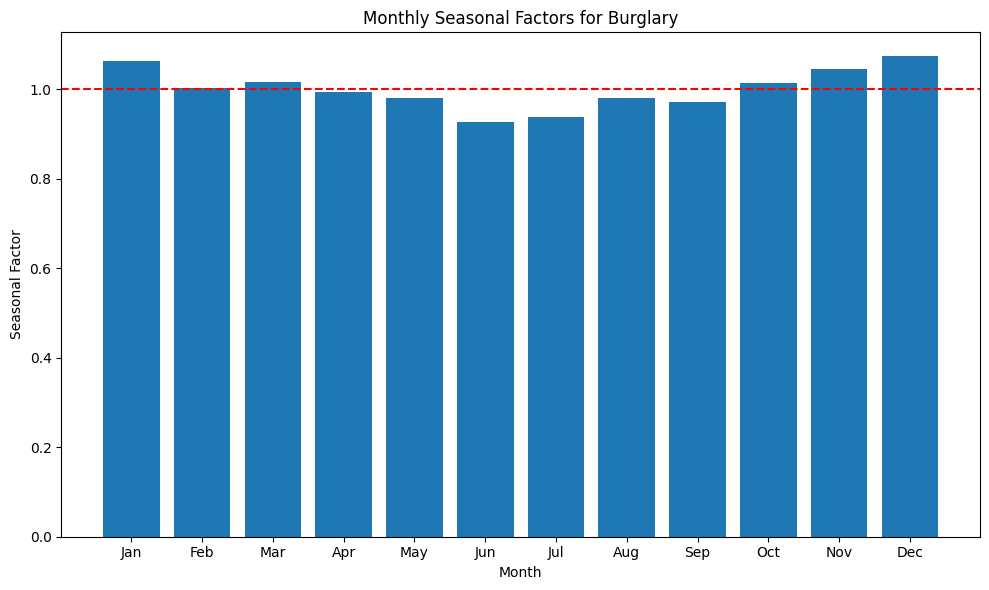

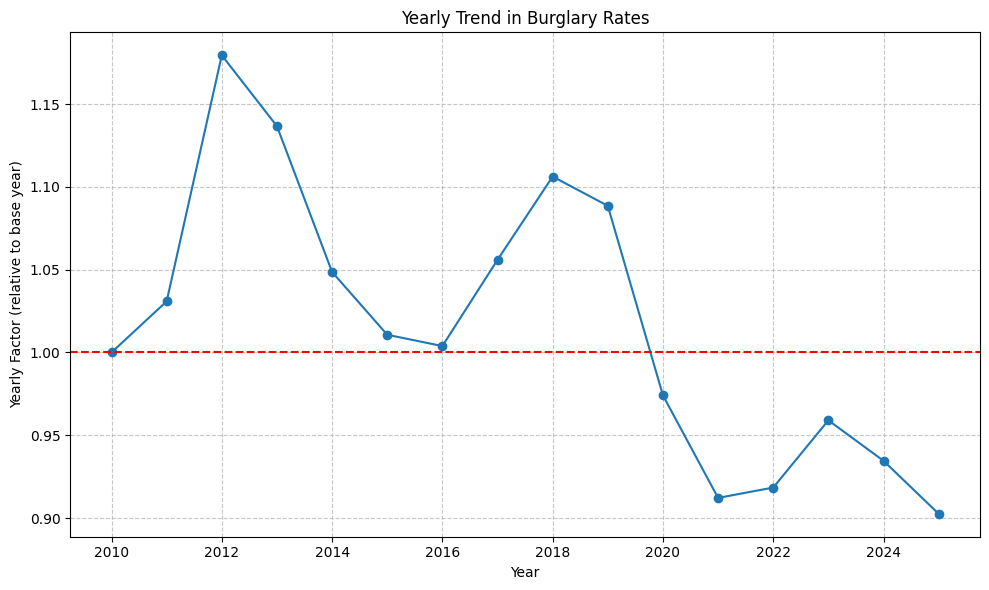

In [32]:
def calculate_seasonal_factors(monthly_counts, football_merged):
    """Calculate monthly seasonal factors for burglary patterns"""
    
    # Prep monthly_avg
    monthly_avg = monthly_counts.groupby('month_num')['burglary_count'].mean().reset_index()
    overall_avg = monthly_counts['burglary_count'].mean()
    monthly_avg['seasonal_factor'] = monthly_avg['burglary_count'] / overall_avg
    monthly_avg['burglary_factor'] = monthly_avg['burglary_count'] / monthly_avg['burglary_count'].mean()

    # Prep football_monthly
    football_avg = football_merged['match_count'].mean()
    football_monthly['match_factor'] = football_monthly['match_count'] / football_avg
    
    # Merge the files on month_num
    merged = pd.merge(
    monthly_avg[['month_num', 'burglary_factor']], 
    football_monthly[['month_num', 'match_factor']], 
    on='month_num')

    # Weigh the factors
    merged['weighted_factor'] = (
    0.95 * merged['burglary_factor'] +
    0.05 * merged['match_factor']
    )
    seasonal_factors = dict(zip(merged['month_num'], merged['weighted_factor']))

    # Monthly factors printed
    print("Monthly seasonal factors:")
    for month_num, factor in seasonal_factors.items():
        month_name = {
            1: 'January', 2: 'February', 3: 'March', 4: 'April',
            5: 'May', 6: 'June', 7: 'July', 8: 'August',
            9: 'September', 10: 'October', 11: 'November', 12: 'December'
        }[month_num]
        print(f"  {month_name}: {factor:.3f}")
    
    # Monthly plot
    plt.figure(figsize=(10, 6))
    plt.bar(merged['month_num'], merged['weighted_factor'])
    plt.axhline(y=1.0, color='r', linestyle='--')
    plt.xticks(merged['month_num'], [
        'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
        'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'
    ])
    plt.xlabel('Month')
    plt.ylabel('Seasonal Factor')
    plt.title('Monthly Seasonal Factors for Burglary')
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'seasonal_factors.png'))
    plt.show()

    # Yearly
    yearly_avg = monthly_counts.groupby('year')['burglary_count'].mean().reset_index()
    base_year_avg = yearly_avg.loc[yearly_avg['year'] == yearly_avg['year'].min(), 'burglary_count'].values[0]
    yearly_avg['yearly_factor'] = yearly_avg['burglary_count'] / base_year_avg

    # Yearly plot
    plt.figure(figsize=(10, 6))
    plt.plot(yearly_avg['year'], yearly_avg['yearly_factor'], marker='o')
    plt.axhline(y=1.0, color='r', linestyle='--')
    plt.xlabel('Year')
    plt.ylabel('Yearly Factor (relative to base year)')
    plt.title('Yearly Trend in Burglary Rates')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'yearly_trend.png'))
    plt.show()
    
    return seasonal_factors, dict(zip(yearly_avg['year'], yearly_avg['yearly_factor']))

seasonal_factors, yearly_factors = calculate_seasonal_factors(monthly_counts, football_merged)

# Feature Engineering

In [33]:
def create_lsoa_features(monthly_counts, socio_data, seasonal_factors, yearly_factors):
    """Create comprehensive features for each LSOA"""
    print("Engineering enhanced features for multi-month GCN model...")
    
    selected_features = [
        'IMD Score'
    ]
    
    lsoa_stats = monthly_counts.groupby('LSOA_code').agg({
        'burglary_count': ['mean', 'std', 'max', 'sum']
    }).reset_index()
    
    lsoa_stats.columns = ['LSOA_code', 'avg_monthly_burglaries', 'std_burglaries', 
                          'max_burglaries', 'total_burglaries']
    
    monthly_averages = monthly_counts.groupby(['LSOA_code', 'month_num'])['burglary_count'].mean().reset_index()
    
    monthly_pivot = monthly_averages.pivot(index='LSOA_code', 
                                          columns='month_num', 
                                          values='burglary_count').reset_index()
    
    month_names = {
        1: 'jan_avg', 2: 'feb_avg', 3: 'mar_avg', 4: 'apr_avg',
        5: 'may_avg', 6: 'jun_avg', 7: 'jul_avg', 8: 'aug_avg',
        9: 'sep_avg', 10: 'oct_avg', 11: 'nov_avg', 12: 'dec_avg'
    }
    
    rename_dict = {}
    for month_num in range(1, 13):
        if month_num in monthly_pivot.columns:
            rename_dict[month_num] = month_names[month_num]
    
    if rename_dict:
        monthly_pivot.rename(columns=rename_dict, inplace=True)
    
    for month_num, month_col in month_names.items():
        if month_col not in monthly_pivot.columns:
            monthly_pivot[month_col] = np.nan
    
    for month_num, month_col in month_names.items():
        mask = monthly_pivot[month_col].isna()
        if mask.any():
            for idx in monthly_pivot.index[mask]:
                lsoa_code = monthly_pivot.loc[idx, 'LSOA_code']
                if lsoa_code in lsoa_stats['LSOA_code'].values:
                    avg_burglaries = lsoa_stats.loc[lsoa_stats['LSOA_code'] == lsoa_code, 'avg_monthly_burglaries'].values[0]
                    monthly_pivot.loc[idx, month_col] = avg_burglaries * seasonal_factors.get(month_num, 1.0)
    
    monthly_counts_sorted = monthly_counts.sort_values(['year', 'month_num'], ascending=False)
    
    recent_data = monthly_counts_sorted.drop_duplicates(['LSOA_code', 'year', 'month_num']).groupby('LSOA_code').head(6)
    recent_avg = recent_data.groupby('LSOA_code')['burglary_count'].mean().reset_index()
    recent_avg.columns = ['LSOA_code', 'recent_avg_burglaries']
    
    lsoa_list = recent_data['LSOA_code'].unique()
    previous_data = monthly_counts_sorted[
        ~monthly_counts_sorted.index.isin(recent_data.index) & 
        monthly_counts_sorted['LSOA_code'].isin(lsoa_list)
    ].groupby('LSOA_code').head(6)
    
    previous_avg = previous_data.groupby('LSOA_code')['burglary_count'].mean().reset_index()
    previous_avg.columns = ['LSOA_code', 'previous_avg_burglaries']
    
    trend_data = recent_avg.merge(previous_avg, on='LSOA_code', how='left')
    trend_data['burglary_trend'] = trend_data['recent_avg_burglaries'] - trend_data['previous_avg_burglaries']
    
    seasonal = monthly_counts.groupby(['LSOA_code', 'month_num'])['burglary_count'].mean().reset_index()
    
    winter_months = [11, 12, 1, 2]
    seasonal['is_winter'] = seasonal['month_num'].isin(winter_months)
    winter_rates = seasonal[seasonal['is_winter']].groupby('LSOA_code')['burglary_count'].mean().reset_index()
    winter_rates.columns = ['LSOA_code', 'winter_burglary_rate']
    
    summer_months = [5, 6, 7, 8]
    seasonal['is_summer'] = seasonal['month_num'].isin(summer_months)
    summer_rates = seasonal[seasonal['is_summer']].groupby('LSOA_code')['burglary_count'].mean().reset_index()
    summer_rates.columns = ['LSOA_code', 'summer_burglary_rate']
    
    try:
        socio_features = socio_data[['LSOA_code'] + selected_features].copy()
    except KeyError:
        socio_features = socio_data.copy()
        socio_features.columns = [col.strip() for col in socio_features.columns]
        
        matched_features = []
        for feature in selected_features:
            feature_match = [col for col in socio_features.columns if feature.strip() in col]
            if feature_match:
                matched_features.append(feature_match[0])
        
        if not matched_features:
            raise ValueError("Could not find any matching socioeconomic features")
        
        socio_features = socio_features[['LSOA_code'] + matched_features]
    
    features = lsoa_stats.merge(trend_data[['LSOA_code', 'burglary_trend']], on='LSOA_code', how='left')
    features = features.merge(monthly_pivot, on='LSOA_code', how='left')
    features = features.merge(winter_rates, on='LSOA_code', how='left')
    features = features.merge(summer_rates, on='LSOA_code', how='left')
    features = features.merge(socio_features, on='LSOA_code', how='left')
    
    features['seasonal_ratio'] = features['winter_burglary_rate'] / features['summer_burglary_rate']
    
    features.fillna(0, inplace=True)
    
    print(f"Created enhanced feature dataset with {len(features)} LSOAs and {len(features.columns)-1} features")
    return features

lsoa_features = create_lsoa_features(monthly_counts, socio_data, seasonal_factors, yearly_factors)

Engineering enhanced features for multi-month GCN model...
Created enhanced feature dataset with 4658 LSOAs and 21 features


# Spatial Graph Construction

In [34]:
def create_adjacency_graph(lsoa_boundaries):
    """Build LSOA adjacency graph for spatial modeling"""
    print("Building LSOA adjacency graph...")
    
    # Ensure unique LSOA codes
    lsoa_boundaries = lsoa_boundaries.drop_duplicates(subset='LSOA_code')
    
    # Create mapping from LSOA codes to indices
    lsoa_codes = lsoa_boundaries['LSOA_code'].values
    lsoa_to_idx = {code: idx for idx, code in enumerate(lsoa_codes)}
    
    # Initialize graph
    G = nx.Graph()
    
    # Add nodes
    for code in lsoa_codes:
        G.add_node(lsoa_to_idx[code], lsoa_code=code)
    
    # Use spatial index for efficient neighbor identification
    spatial_index = lsoa_boundaries.sindex
    
    # Track progress
    total = len(lsoa_boundaries)
    edges_added = 0
    
    # Add edges based on adjacency
    for idx, lsoa in lsoa_boundaries.iterrows():
        if idx % 100 == 0:
            pass
        
        try:
            # Find potential neighbors using spatial index
            possible_neighbors_idx = list(spatial_index.intersection(lsoa.geometry.bounds))
            possible_neighbors = lsoa_boundaries.iloc[possible_neighbors_idx]
            
            # Filter to actual neighbors (those that share a boundary)
            neighbors = possible_neighbors[possible_neighbors.geometry.touches(lsoa.geometry)]
            
            # Add graph edges
            for _, neighbor in neighbors.iterrows():
                if neighbor['LSOA_code'] != lsoa['LSOA_code']:  # Avoid self-loops
                    idx_i = lsoa_to_idx[lsoa['LSOA_code']]
                    idx_j = lsoa_to_idx[neighbor['LSOA_code']]
                    
                    if not G.has_edge(idx_i, idx_j):
                        G.add_edge(idx_i, idx_j)
                        edges_added += 1
        except Exception as e:
            print(f"Error processing LSOA {lsoa['LSOA_code']}: {e}")
    
    print(f"Created graph with {len(G.nodes)} nodes and {edges_added} edges")
    
    # Convert to PyTorch Geometric format
    edge_index = []
    for edge in G.edges():
        # Add both directions for undirected graph
        edge_index.append([edge[0], edge[1]])
        edge_index.append([edge[1], edge[0]])
    
    edge_index_tensor = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    
    # Ensure all indices are within valid range
    max_node = len(lsoa_codes) - 1
    mask = (edge_index_tensor[0] <= max_node) & (edge_index_tensor[1] <= max_node)
    edge_index_filtered = edge_index_tensor[:, mask].contiguous()
    
    # Transfer edge_index to device (GPU)
    edge_index_filtered = edge_index_filtered.to(device)
    
    return G, edge_index_filtered, lsoa_to_idx

# Create spatial graph structure
G, edge_index, lsoa_to_idx = create_adjacency_graph(lsoa_boundaries)

Building LSOA adjacency graph...
Created graph with 4658 nodes and 13278 edges


# Model Architecture Definition

In [35]:
class MultiMonthLSTMGCNModel(torch.nn.Module):
    """Enhanced LSTM-GCN Hybrid Model for Multi-Month Predictions"""
    
    def __init__(self, num_features, sequence_length=36, target_months=None):
        super(MultiMonthLSTMGCNModel, self).__init__()
        
        # Set target months
        if target_months is None:
            target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November
        
        self.target_months = target_months
        self.num_months = len(target_months)
        
        # Initial feature projection layer
        self.feature_proj = torch.nn.Linear(num_features, 64)
        
        # GCN Layers for spatial feature extraction
        self.conv1 = GCNConv(64, 64)
        self.conv2 = GCNConv(64, 32)
        self.conv3 = GCNConv(32, 16)
        
        # Temporal sequence projection to match LSTM input size
        self.temporal_proj = torch.nn.Linear(1, 16)
        
        # LSTM Layer for temporal pattern recognition
        self.lstm = nn.LSTM(
            input_size=16,  # Projected temporal features
            hidden_size=64,  # Increased hidden layer size
            num_layers=2,   # Number of LSTM layers
            batch_first=True,
            dropout=0.3     # Increased dropout for regularization
        )
        
        # Attention mechanism for focusing on relevant time steps
        self.attention = nn.Linear(64, 1)
        
        # Shared features layer
        self.shared_features = torch.nn.Linear(64, 32)
        
        # Month-specific prediction layers
        self.month_predictors = nn.ModuleList([
            nn.Sequential(
                nn.Linear(32, 16),
                nn.ReLU(),
                nn.Linear(16, 1)
            ) for _ in range(self.num_months)
        ])
        
        # Store sequence length for reshaping
        self.sequence_length = sequence_length
    
    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        
        # Validate and filter edge_index
        def filter_edge_index(edge_index, num_nodes):
            mask = (edge_index[0] < num_nodes) & (edge_index[1] < num_nodes)
            return edge_index[:, mask]
        
        # Filter edge_index to match number of nodes
        num_nodes = x.size(0)
        edge_index = filter_edge_index(edge_index, num_nodes)
        
        # Project initial features to consistent dimension
        x = F.relu(self.feature_proj(x))
        
        # Graph Convolution Layers
        try:
            x = self.conv1(x, edge_index)
            x = F.relu(x)
            x = F.dropout(x, p=0.3, training=self.training)
            
            x = self.conv2(x, edge_index)
            x = F.relu(x)
            
            x = self.conv3(x, edge_index)
            x = F.relu(x)
        except RuntimeError as e:
            print(f"Error in graph convolution: {e}")
            print(f"x shape: {x.shape}, edge_index shape: {edge_index.shape}")
            raise
        
        # Reshape for LSTM (separate spatial and temporal components)
        batch_size = x.size(0)
        
        # Extract and project temporal sequence to match LSTM input
        temporal_input = data.x[:, -self.sequence_length:].view(batch_size, self.sequence_length, 1)
        temporal_input = self.temporal_proj(temporal_input)
        
        # LSTM Processing
        lstm_out, (hidden, cell) = self.lstm(temporal_input)
        
        # Apply attention to focus on important time steps
        attention_scores = self.attention(lstm_out).squeeze(2)
        attention_weights = F.softmax(attention_scores, dim=1).unsqueeze(2)
        context_vector = torch.sum(lstm_out * attention_weights, dim=1)
        
        # Generate shared features
        shared_features = F.relu(self.shared_features(context_vector))
        
        # Generate predictions for each month
        month_predictions = []
        for i, month_predictor in enumerate(self.month_predictors):
            month_pred = month_predictor(shared_features)
            month_predictions.append(month_pred)
        
        # Stack month predictions into tensor of shape [batch_size, num_months]
        return torch.cat(month_predictions, dim=1)

# Define target months for 2025 predictions
target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November

print(f"Model will predict for {len(target_months)} months: {target_months}")

Model will predict for 9 months: [3, 4, 5, 6, 7, 8, 9, 10, 11]


# Training Data Preparation

In [36]:
def prepare_multimonth_gcn_data(lsoa_features, edge_index, monthly_counts, seasonal_factors, target_months=None, sequence_length=36):
    """Prepare data for multi-month LSTM-GCN model"""
    print(f"Preparing data for multi-month LSTM-GCN model with sequence length {sequence_length}...")
    
    if target_months is None:
        target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November
    
    month_names = {
        1: 'January', 2: 'February', 3: 'March', 4: 'April',
        5: 'May', 6: 'June', 7: 'July', 8: 'August',
        9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }
    
    print(f"Target months: {', '.join([month_names[m] for m in target_months])}")
    
    # Ensure features are in the correct order
    lsoa_features = lsoa_features.sort_values('LSOA_code')
    
    # Select numerical features (exclude month-specific columns)
    month_cols = ['jan_avg', 'feb_avg', 'mar_avg', 'apr_avg', 'may_avg', 
                 'jun_avg', 'jul_avg', 'aug_avg', 'sep_avg', 'oct_avg', 
                 'nov_avg', 'dec_avg']
    
    spatial_feature_cols = [col for col in lsoa_features.columns 
                           if col not in ['LSOA_code'] + month_cols and 
                           lsoa_features[col].dtype in ['int64', 'float64']]
    
    # Normalize spatial features
    scaler = StandardScaler()
    lsoa_features[spatial_feature_cols] = scaler.fit_transform(lsoa_features[spatial_feature_cols])
    
    def create_sequences(features, monthly_data, lsoa_code, seq_length=sequence_length):
        """Create temporal sequences for each LSOA"""
        # Sort monthly data chronologically for this LSOA
        monthly_sorted = monthly_data[monthly_data['LSOA_code'] == lsoa_code].sort_values(['year', 'month_num'])
        
        # Extract burglary counts
        burglary_seq = monthly_sorted['burglary_count'].values
        
        # If not enough data, pad with zeros
        if len(burglary_seq) < seq_length:
            burglary_seq = np.pad(burglary_seq, (seq_length - len(burglary_seq), 0), mode='constant')
        else:
            # Take the last seq_length entries
            burglary_seq = burglary_seq[-seq_length:]
        
        # Get the most recent features
        lsoa_row = features[features['LSOA_code'] == lsoa_code][spatial_feature_cols].values[0]
        
        return burglary_seq, lsoa_row
    
    # Prepare sequences for each LSOA
    X_sequences = []
    Y_targets = []
    
    unique_lsoas = lsoa_features['LSOA_code'].unique()
    
    for lsoa_code in unique_lsoas:
        try:
            # Get historical sequence and spatial features
            seq, features = create_sequences(lsoa_features, monthly_counts, lsoa_code, sequence_length)
            
            # Get monthly averages with seasonal adjustments
            lsoa_row = lsoa_features[lsoa_features['LSOA_code'] == lsoa_code]
            
            # Create target vector for multi-month prediction
            base_value = lsoa_row['avg_monthly_burglaries'].values[0]
            
            # Create month-specific targets using seasonal factors
            month_targets = []
            for month in target_months:
                month_col = f"{month_names[month].lower()[:3]}_avg"
                if month_col in lsoa_row.columns and not pd.isna(lsoa_row[month_col].values[0]):
                    month_targets.append(lsoa_row[month_col].values[0])
                else:
                    month_targets.append(base_value * seasonal_factors.get(month, 1.0))
            
            # Combine features and sequence
            combined_features = np.concatenate([features, seq])
            
            X_sequences.append(combined_features)
            Y_targets.append(month_targets)
        except Exception as e:
            print(f"Error processing LSOA {lsoa_code}: {e}")
    
    # Convert to tensors and move to device
    X_features = torch.tensor(X_sequences, dtype=torch.float).to(device)
    Y_targets = torch.tensor(Y_targets, dtype=torch.float).to(device)
    
    # Create PyTorch Geometric Data object
    data = Data(x=X_features, edge_index=edge_index, y=Y_targets)
    
    print(f"Prepared multi-month GCN data:")
    print(f"X_features shape: {X_features.shape}")
    print(f"Y_targets shape: {Y_targets.shape}")
    print(f"edge_index shape: {edge_index.shape}")
    
    return data, spatial_feature_cols + [f'seq_{i}' for i in range(sequence_length)]

def train_test_split_gcn(data, test_size=0.2, random_seed=42):
    """Perform train-test split for graph-based data"""
    # Set random seed for reproducibility
    torch.manual_seed(random_seed)
    np.random.seed(random_seed)
    
    # Total number of samples
    total_samples = data.x.shape[0]
    
    # Calculate split indices
    test_samples = int(total_samples * test_size)
    train_samples = total_samples - test_samples
    
    # Create random permutation of indices
    indices = torch.randperm(total_samples, device=data.x.device)
    
    # Split indices
    train_indices = indices[:train_samples]
    test_indices = indices[train_samples:]
    
    # Create train and test data
    train_data = Data(
        x=data.x[train_indices],
        edge_index=data.edge_index,
        y=data.y[train_indices]
    )
    
    test_data = Data(
        x=data.x[test_indices],
        edge_index=data.edge_index,
        y=data.y[test_indices]
    )
    
    return train_data, test_data, train_indices, test_indices

# Determine sequence length based on available data
month_count = monthly_counts[['year', 'month_num']].drop_duplicates().shape[0]
sequence_length = min(36, month_count)
print(f"Setting sequence length to {sequence_length} based on available data spanning {month_count} months")

# Prepare data for multi-month predictions
data, feature_cols = prepare_multimonth_gcn_data(
    lsoa_features, 
    edge_index, 
    monthly_counts,
    seasonal_factors,
    target_months,
    sequence_length
)

# Perform train-test split
train_data, test_data, train_indices, test_indices = train_test_split_gcn(data)

Setting sequence length to 36 based on available data spanning 171 months
Preparing data for multi-month LSTM-GCN model with sequence length 36...
Target months: March, April, May, June, July, August, September, October, November
Prepared multi-month GCN data:
X_features shape: torch.Size([4658, 45])
Y_targets shape: torch.Size([4658, 9])
edge_index shape: torch.Size([2, 26556])


 # Model Training

Model moved to device: cuda:0
Training multi-month LSTM-GCN model with early stopping (max epochs: 300, patience: 30)...
Epoch 20/300, Train Loss: 0.6593, Val Loss: 0.4692
Epoch 40/300, Train Loss: 0.5131, Val Loss: 0.3512
Epoch 60/300, Train Loss: 0.5066, Val Loss: 0.3406
Epoch 80/300, Train Loss: 0.4190, Val Loss: 0.2658
Epoch 100/300, Train Loss: 0.2847, Val Loss: 0.1998
Epoch 120/300, Train Loss: 0.2183, Val Loss: 0.1928
Epoch 140/300, Train Loss: 0.2042, Val Loss: 0.1918
Epoch 160/300, Train Loss: 0.1992, Val Loss: 0.1916
Epoch 180/300, Train Loss: 0.2014, Val Loss: 0.2147
Early stopping triggered at epoch 195
Final Training Loss: 0.1986
Final Validation Loss: 0.1907
Best Validation Loss: 0.1876


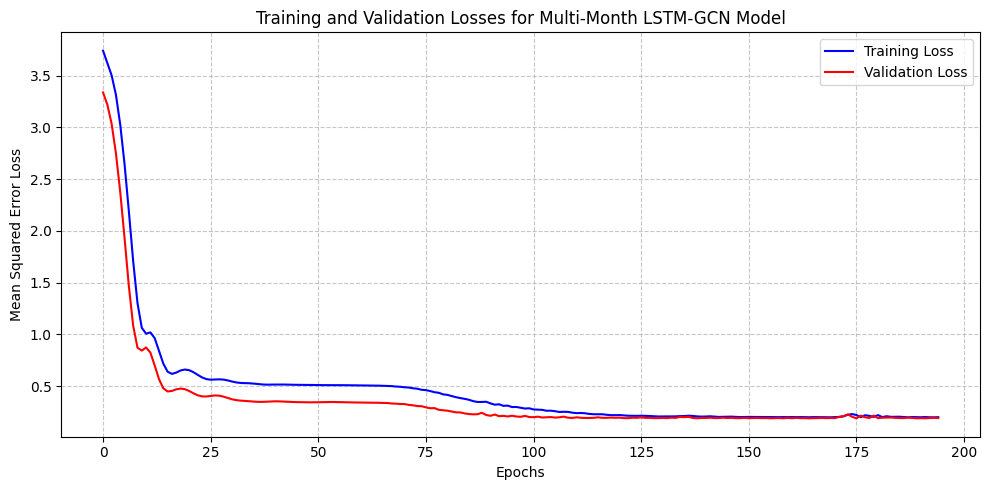

In [37]:
def train_multimonth_lstm_gcn_model(model, train_data, val_data=None, epochs=300, patience=30):
    """Train multi-month LSTM-GCN model with early stopping"""
    print(f"Training multi-month LSTM-GCN model with early stopping (max epochs: {epochs}, patience: {patience})...")
    
    # If validation data not provided, create a split from training data
    if val_data is None:
        val_size = int(train_data.x.size(0) * 0.2)
        train_size = train_data.x.size(0) - val_size
        
        indices = torch.randperm(train_data.x.size(0), device=train_data.x.device)
        train_indices = indices[:train_size]
        val_indices = indices[train_size:]
        
        val_data = Data(
            x=train_data.x[val_indices],
            edge_index=train_data.edge_index,
            y=train_data.y[val_indices]
        )
        
        train_data = Data(
            x=train_data.x[train_indices],
            edge_index=train_data.edge_index,
            y=train_data.y[train_indices]
        )
    
    # Define optimizer and loss function
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    criterion = torch.nn.MSELoss()
    
    # Learning rate scheduler
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min', 
        factor=0.5, 
        patience=20
    )
    
    # Early stopping variables
    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    
    # Tracking losses
    train_losses = []
    val_losses = []
    
    # Training loop
    for epoch in range(epochs):
        # Training phase
        model.train()
        optimizer.zero_grad()
        out = model(train_data)
        train_loss = criterion(out, train_data.y)
        train_loss.backward()
        optimizer.step()
        
        # Validation phase
        model.eval()
        with torch.no_grad():
            val_out = model(val_data)
            val_loss = criterion(val_out, val_data.y)
        
        # Step learning rate
        scheduler.step(val_loss)
        
        # Record losses
        train_losses.append(train_loss.item())
        val_losses.append(val_loss.item())
        
        # Early stopping check
        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping triggered at epoch {epoch+1}")
                model.load_state_dict(best_model_state)
                break
        
        # Print progress periodically
        if (epoch + 1) % 20 == 0:
            print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss.item():.4f}, Val Loss: {val_loss.item():.4f}")
    
    print(f"Final Training Loss: {train_loss.item():.4f}")
    print(f"Final Validation Loss: {val_loss.item():.4f}")
    print(f"Best Validation Loss: {best_val_loss:.4f}")
    
    # Visualization of training and validation losses
    plt.figure(figsize=(10, 5))
    plt.plot(train_losses, label='Training Loss', color='blue')
    plt.plot(val_losses, label='Validation Loss', color='red')
    plt.title('Training and Validation Losses for Multi-Month LSTM-GCN Model')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error Loss')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'multimonth_lstm_gcn_train_val_loss.png'))
    plt.show()
    
    return {
        'train_losses': train_losses, 
        'val_losses': val_losses,
        'best_val_loss': best_val_loss,
        'epochs_trained': len(train_losses)
    }

# Initialize model and move to device
model = MultiMonthLSTMGCNModel(
    num_features=len(feature_cols),
    sequence_length=sequence_length,
    target_months=target_months
).to(device)

print(f"Model moved to device: {next(model.parameters()).device}")

# Train model
training_results = train_multimonth_lstm_gcn_model(model, train_data, test_data, epochs=300, patience=30)

In [38]:
# Save Model Weights

torch.save(model.state_dict(), os.path.join(RESULTS_DIR, 'model_weights.pth'))
print(f"Model weights saved to {RESULTS_DIR}/model_weights.pth")

Model weights saved to /kaggle/working//model_weights.pth


# Model Evaluation

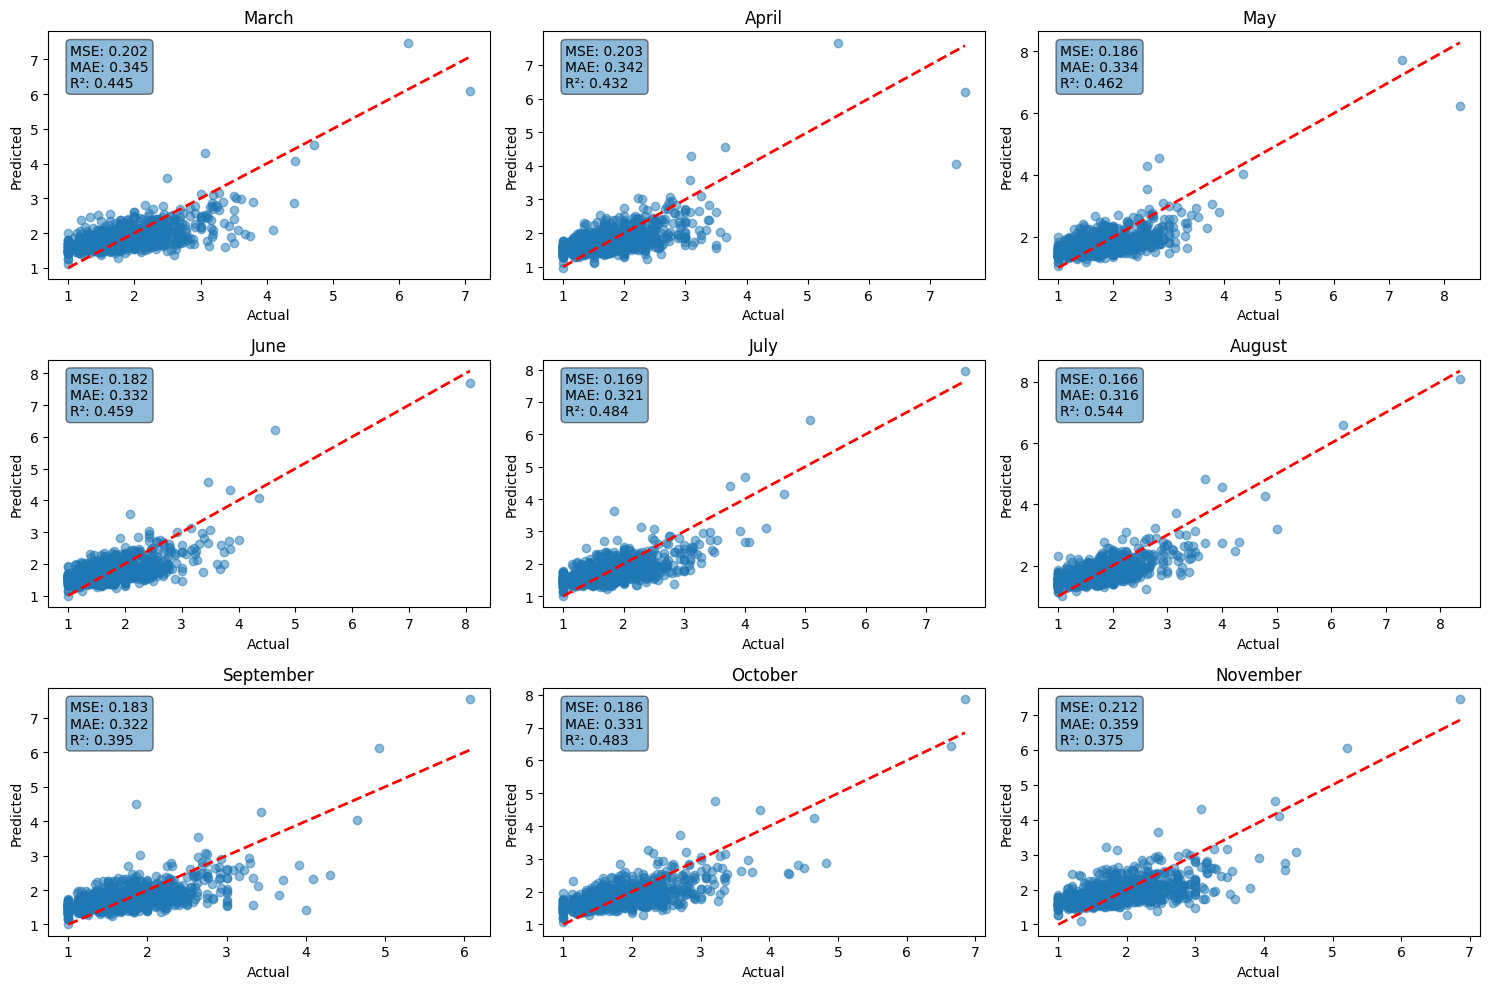


Model Performance Metrics:
Overall MSE: 0.1876
Overall MAE: 0.3338
Overall R²: 0.4533

Month-specific metrics:
  March: MSE=0.2020, MAE=0.3453, R²=0.4449
  April: MSE=0.2033, MAE=0.3425, R²=0.4324
  May: MSE=0.1862, MAE=0.3345, R²=0.4617
  June: MSE=0.1817, MAE=0.3322, R²=0.4592
  July: MSE=0.1688, MAE=0.3205, R²=0.4840
  August: MSE=0.1662, MAE=0.3163, R²=0.5440
  September: MSE=0.1829, MAE=0.3224, R²=0.3946
  October: MSE=0.1856, MAE=0.3315, R²=0.4833
  November: MSE=0.2119, MAE=0.3586, R²=0.3753


In [43]:
def evaluate_multimonth_model(model, test_data, target_months=None):
    """Evaluate the multi-month model with comprehensive metrics"""
    
    if target_months is None:
        target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November
    
    month_names = {
        1: 'January', 2: 'February', 3: 'March', 4: 'April',
        5: 'May', 6: 'June', 7: 'July', 8: 'August',
        9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }
    
    # Set model to evaluation mode
    model.eval()
    
    with torch.no_grad():
        # Make predictions
        predicted = model(test_data)
        
        # Convert to numpy for sklearn metrics
        y_true = test_data.y.cpu().numpy()
        y_pred = predicted.cpu().numpy()
        
        # Overall metrics
        mse = mean_squared_error(y_true, y_pred)
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)
        mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5))) * 100
        
        # Month-specific metrics
        month_metrics = {}
        for i, month in enumerate(target_months):
            month_name = month_names[month]
            month_metrics[month_name] = {
                'MSE': mean_squared_error(y_true[:, i], y_pred[:, i]),
                'MAE': mean_absolute_error(y_true[:, i], y_pred[:, i]),
                'R²': r2_score(y_true[:, i], y_pred[:, i]),
                'MAPE': np.mean(np.abs((y_true[:, i] - y_pred[:, i]) / (y_true[:, i] + 1e-5))) * 100,
                'Avg_True': np.mean(y_true[:, i]),
                'Avg_Pred': np.mean(y_pred[:, i])
            }
        
        # Create scatter plots for each month
        plt.figure(figsize=(15, 10))
        
        n_cols = 3
        n_rows = (len(target_months) + n_cols - 1) // n_cols
        
        for i, month in enumerate(target_months):
            month_name = month_names[month]
            ax = plt.subplot(n_rows, n_cols, i + 1)
            
            ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.5)
            ax.plot([y_true[:, i].min(), y_true[:, i].max()], 
                   [y_true[:, i].min(), y_true[:, i].max()], 'r--', lw=2)
            
            ax.set_title(f'{month_name}')
            ax.set_xlabel('Actual')
            ax.set_ylabel('Predicted')
            
            metrics_text = (f"MSE: {month_metrics[month_name]['MSE']:.3f}\n"
                         f"MAE: {month_metrics[month_name]['MAE']:.3f}\n"
                         f"R²: {month_metrics[month_name]['R²']:.3f}")
            ax.text(0.05, 0.95, metrics_text, transform=ax.transAxes, 
                   verticalalignment='top', bbox={'boxstyle': 'round', 'alpha': 0.5})
        
        plt.tight_layout()
        plt.savefig(os.path.join(RESULTS_DIR, 'multimonth_predicted_vs_actual.png'))
        plt.show()
        
        # Create metrics summary table
        metrics_df = pd.DataFrame({
            'Month': [month_names[m] for m in target_months],
            'MSE': [month_metrics[month_names[m]]['MSE'] for m in target_months],
            'MAE': [month_metrics[month_names[m]]['MAE'] for m in target_months],
            'R²': [month_metrics[month_names[m]]['R²'] for m in target_months],
            'MAPE (%)': [month_metrics[month_names[m]]['MAPE'] for m in target_months],
            'Avg_True': [month_metrics[month_names[m]]['Avg_True'] for m in target_months],
            'Avg_Pred': [month_metrics[month_names[m]]['Avg_Pred'] for m in target_months]
        })
        
        metrics_df.to_csv(os.path.join(RESULTS_DIR, 'multimonth_model_metrics.csv'), index=False)
        
        return {
            'Overall MSE': mse,
            'Overall MAE': mae,
            'Overall R²': r2,
            'Overall MAPE': mape,
            'Month Metrics': month_metrics,
            'Metrics DataFrame': metrics_df
        }

# Evaluate model
test_metrics = evaluate_multimonth_model(model, test_data, target_months)

# Print evaluation metrics
print("\nModel Performance Metrics:")
print(f"Overall MSE: {test_metrics['Overall MSE']:.4f}")
print(f"Overall MAE: {test_metrics['Overall MAE']:.4f}")
print(f"Overall R²: {test_metrics['Overall R²']:.4f}")

month_names = {
    1: 'January', 2: 'February', 3: 'March', 4: 'April',
    5: 'May', 6: 'June', 7: 'July', 8: 'August',
    9: 'September', 10: 'October', 11: 'November', 12: 'December'
}

print("\nMonth-specific metrics:")
for month in target_months:
    month_name = month_names[month]
    metrics = test_metrics['Month Metrics'][month_name]
    print(f"  {month_name}: MSE={metrics['MSE']:.4f}, MAE={metrics['MAE']:.4f}, R²={metrics['R²']:.4f}")

# Risk Prediction Generation

In [ ]:
def generate_monthly_predictions(model, data, lsoa_features, target_months=None):
    """Generate risk predictions for each target month"""
    print("Generating monthly risk predictions for 2025...")
    
    if target_months is None:
        target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November
    
    month_names = {
        1: 'January', 2: 'February', 3: 'March', 4: 'April',
        5: 'May', 6: 'June', 7: 'July', 8: 'August',
        9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }
    
    # Set model to evaluation mode
    model.eval()
    
    # Generate predictions
    with torch.no_grad():
        predicted_risks = model(data).cpu().numpy()
    
    # Create prediction results
    results = lsoa_features[['LSOA_code']].copy()
    
    # Add raw predictions for each month
    for i, month in enumerate(target_months):
        month_name = month_names[month]
        results[f'predicted_risk_{month_name}_2025'] = predicted_risks[:, i]
    
    # Normalize risk scores to 0-100 scale for each month
    for month in target_months:
        month_name = month_names[month]
        col = f'predicted_risk_{month_name}_2025'
        min_risk = results[col].min()
        max_risk = results[col].max()
        results[f'risk_score_{month_name}_2025'] = ((results[col] - min_risk) / 
                                          (max_risk - min_risk)) * 100
    
    # Create an overall average risk score
    risk_score_columns = [f'risk_score_{month_names[month]}_2025' for month in target_months]
    results['average_risk_score_2025'] = results[risk_score_columns].mean(axis=1)
    
    print(f"Generated monthly risk predictions for {len(results)} LSOAs")
    
    # Save predictions to CSV
    results.to_csv(os.path.join(RESULTS_DIR, 'monthly_risk_predictions_2025.csv'), index=False)
    print(f"Monthly prediction results saved at {RESULTS_DIR}")
    
    return results

# Generate predictions for all months
risk_predictions = generate_monthly_predictions(model, data, lsoa_features, target_months)

# Display summary statistics
print("\nRisk Score Summary Statistics:")
for month in target_months:
    month_name = month_names[month]
    col = f'risk_score_{month_name}_2025'
    print(f"{month_name}: Mean={risk_predictions[col].mean():.2f}, Std={risk_predictions[col].std():.2f}")

print(f"\nAverage Risk Score: Mean={risk_predictions['average_risk_score_2025'].mean():.2f}, Std={risk_predictions['average_risk_score_2025'].std():.2f}")

# Risk Visualization and Mapping

In [ ]:
def create_monthly_risk_maps(boundaries, risk_data, target_months=None):
    """Create risk maps for each target month"""
    print("Creating monthly burglary risk heatmaps...")
    
    if target_months is None:
        target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November
    
    month_names = {
        1: 'January', 2: 'February', 3: 'March', 4: 'April',
        5: 'May', 6: 'June', 7: 'July', 8: 'August',
        9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }
    
    # Merge boundaries with risk predictions
    risk_map = boundaries.merge(risk_data, on='LSOA_code', how='inner')
    
    def custom_risk_categorization(series):
        """Create custom risk categories based on percentiles"""
        return pd.qcut(series, q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    
    # Create a map for each month
    risk_maps = {}
    
    for month in target_months:
        month_name = month_names[month]
        print(f"Creating map for {month_name} 2025...")
        
        risk_col = f'risk_score_{month_name}_2025'
        category_col = f'risk_category_{month_name}_2025'
        
        if risk_col in risk_map.columns:
            try:
                risk_map[category_col] = custom_risk_categorization(risk_map[risk_col])
            except ValueError as e:
                print(f"Warning: Could not categorize {risk_col}: {e}")
                risk_map[category_col] = pd.cut(risk_map[risk_col], 
                                              bins=[0, 20, 40, 60, 80, 100],
                                              labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'],
                                              include_lowest=True)
            
            # Set up figure and axis
            fig, ax = plt.subplots(1, 1, figsize=(12, 10))
            
            # Plot the map with risk colors
            risk_map.plot(column=risk_col, 
                         cmap='RdYlGn_r', 
                         linewidth=0.1,
                         edgecolor='0.5',
                         legend=True,
                         ax=ax)
            
            # Customize the plot
            ax.set_title(f'Predicted Burglary Risk for {month_name} 2025\nLSOA Level', fontsize=16)
            ax.set_axis_off()
            
            # Add a colorbar
            sm = plt.cm.ScalarMappable(cmap='RdYlGn_r')
            sm.set_array(risk_map[risk_col])
            cbar = fig.colorbar(sm, ax=ax)
            cbar.set_label('Risk Score (Higher = Greater Risk)', fontsize=12)
            
            # Add model information
            plt.figtext(0.1, 0.01, 
                       "Model: Multi-Month LSTM-GCN incorporating spatial and temporal patterns\n" +
                       "Date: May 2025", 
                       ha="left", fontsize=10)
            
            # Save the figure
            output_file = f'london_burglary_risk_map_{month_name.lower()}_2025.png'
            plt.savefig(os.path.join(RESULTS_DIR, output_file), dpi=300, bbox_inches='tight')
            plt.show()
            
            print(f"Saved {month_name} risk map to {os.path.join(RESULTS_DIR, output_file)}")
            
            # Store the map
            risk_maps[month_name] = risk_map.copy()
    
    # Create an average risk map
    if 'average_risk_score_2025' in risk_map.columns:
        risk_map['risk_category_average_2025'] = custom_risk_categorization(risk_map['average_risk_score_2025'])
        
        fig, ax = plt.subplots(1, 1, figsize=(12, 10))
        
        risk_map.plot(column='average_risk_score_2025', 
                     cmap='RdYlGn_r', 
                     linewidth=0.1,
                     edgecolor='0.5',
                     legend=True,
                     ax=ax)
        
        ax.set_title('Average Predicted Burglary Risk for 2025\nLSOA Level', fontsize=16)
        ax.set_axis_off()
        
        sm = plt.cm.ScalarMappable(cmap='RdYlGn_r')
        sm.set_array(risk_map['average_risk_score_2025'])
        cbar = fig.colorbar(sm, ax=ax)
        cbar.set_label('Average Risk Score (Higher = Greater Risk)', fontsize=12)
        
        plt.figtext(0.1, 0.01, 
                   "Model: Multi-Month LSTM-GCN incorporating spatial and temporal patterns\n" +
                   "Data: Average prediction across all target months in 2025", 
                   ha="left", fontsize=10)
        
        output_file = 'london_burglary_risk_map_average_2025.png'
        plt.savefig(os.path.join(RESULTS_DIR, output_file), dpi=300, bbox_inches='tight')
        plt.show()
        
        print(f"Saved average risk map to {os.path.join(RESULTS_DIR, output_file)}")
        risk_maps['Average'] = risk_map.copy()
    
    return risk_maps

# Create visualizations
risk_maps = create_monthly_risk_maps(lsoa_boundaries, risk_predictions, target_months)

# Seasonal Trend Analysis

In [ ]:
def create_seasonal_trend_analysis(risk_data, target_months=None):
    """Create visualizations showing seasonal trends in risk predictions"""
    print("Creating seasonal trend analysis...")
    
    if target_months is None:
        target_months = [3, 4, 5, 6, 7, 8, 9, 10, 11]  # March through November
    
    month_names = {
        1: 'January', 2: 'February', 3: 'March', 4: 'April',
        5: 'May', 6: 'June', 7: 'July', 8: 'August',
        9: 'September', 10: 'October', 11: 'November', 12: 'December'
    }
    
    # Extract risk scores for each month
    risk_cols = [f'risk_score_{month_names[month]}_2025' for month in target_months]
    risk_data_subset = risk_data[['LSOA_code'] + risk_cols].copy()
    
    # Calculate overall statistics for each LSOA
    risk_data_subset['avg_risk'] = risk_data_subset[risk_cols].mean(axis=1)
    risk_data_subset['risk_std'] = risk_data_subset[risk_cols].std(axis=1)
    risk_data_subset['risk_max'] = risk_data_subset[risk_cols].max(axis=1)
    risk_data_subset['risk_min'] = risk_data_subset[risk_cols].min(axis=1)
    risk_data_subset['risk_range'] = risk_data_subset['risk_max'] - risk_data_subset['risk_min']
    
    # Create box plot of risk distributions by month
    plt.figure(figsize=(12, 6))
    
    boxplot_data = []
    boxplot_labels = []
    
    for month in target_months:
        month_name = month_names[month]
        col = f'risk_score_{month_name}_2025'
        boxplot_data.append(risk_data[col])
        boxplot_labels.append(month_name)
    
    plt.boxplot(boxplot_data, labels=boxplot_labels)
    plt.title('Distribution of Burglary Risk Scores Across London by Month (2025)', fontsize=14)
    plt.ylabel('Risk Score (0-100)', fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Color code by seasons
    winter_months = [11, 12, 1, 2]
    spring_months = [3, 4, 5]
    summer_months = [6, 7, 8]
    autumn_months = [9, 10]
    
    for i, month in enumerate(target_months):
        if month in winter_months:
            color = 'blue'
            season = 'Winter'
        elif month in spring_months:
            color = 'green'
            season = 'Spring'
        elif month in summer_months:
            color = 'red'
            season = 'Summer'
        else:  # autumn
            color = 'orange'
            season = 'Autumn'
        
        plt.gca().get_xticklabels()[i].set_color(color)
        plt.gca().get_xticklabels()[i].set_fontweight('bold')
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'seasonal_risk_distribution_2025.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Create line chart of average risk by month
    plt.figure(figsize=(12, 6))
    
    avg_by_month = [risk_data[f'risk_score_{month_names[month]}_2025'].mean() for month in target_months]
    
    plt.plot(boxplot_labels, avg_by_month, marker='o', linestyle='-', linewidth=2, markersize=8)
    
    plt.title('Average Burglary Risk Across London by Month (2025)', fontsize=14)
    plt.ylabel('Average Risk Score', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    
    # Add season colors to data points
    for i, month in enumerate(target_months):
        if month in winter_months:
            color = 'blue'
        elif month in spring_months:
            color = 'green'
        elif month in summer_months:
            color = 'red'
        else:  # autumn
            color = 'orange'
        
        plt.plot(boxplot_labels[i], avg_by_month[i], 'o', color=color, markersize=10)
    
    plt.tight_layout()
    plt.savefig(os.path.join(RESULTS_DIR, 'average_risk_by_month_2025.png'), dpi=300, bbox_inches='tight')
    plt.show()
    
    # Save the analysis
    risk_data_subset.to_csv(os.path.join(RESULTS_DIR, 'seasonal_risk_analysis_2025.csv'), index=False)
    
    print(f"Seasonal trend analysis saved to {RESULTS_DIR}")
    
    return risk_data_subset

# Create seasonal trend analysis
seasonal_analysis = create_seasonal_trend_analysis(risk_predictions, target_months)